In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
import numpy as np
sys.path.append("..")

In [7]:
from src.assay_calibration.data_utils.dataset import Scoreset

In [ ]:
from pathlib import Path
fits_dir = Path("test/test_fits")
seed_to_best_fit = {}
for fit_file in fits_dir.glob("*.json"):
    # read the fit
    with open(fit_file) as f:
        fit = json.load(f)
    # get the bootstrap seed
    bootstrap_seed = fit['bootstrap_seed']
    # save the fit if it is the first fit for this seed
    if bootstrap_seed not in seed_to_best_fit:
        fit['fit']['weights'] = np.array(fit['fit']['weights'])
        seed_to_best_fit[bootstrap_seed] = fit
        continue
    # save the fit if it has a better log likelihood than the previous best fit
    if seed_to_best_fit[bootstrap_seed]['val_ll'] < fit['val_ll']:
        fit['fit']['weights'] = np.array(fit['fit']['weights'])
        seed_to_best_fit[bootstrap_seed] = fit
fits = list(seed_to_best_fit.values())

In [27]:
scoreset = Scoreset.from_json("/data/dzeiberg/pillar_project/pillar_project_data/dataset_09192025/scoresets/BRCA1_Adamovich_2022_HDR.json")

In [28]:
from src.assay_calibration.fit_utils.two_sample.density_utils import joint_densities

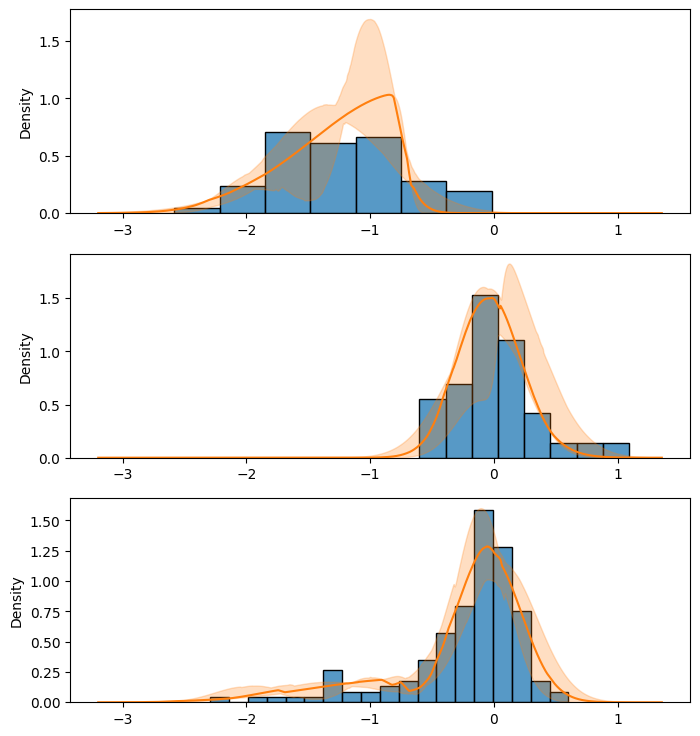

In [38]:
fig,ax = plt.subplots(scoreset.sample_assignments.shape[1],1,figsize=(8,3 * scoreset.sample_assignments.shape[1]))
score_range = np.linspace(scoreset.scores.min(),scoreset.scores.max(),1000)
for sampleIdx,axi in enumerate(ax):
    sns.histplot(scoreset.scores[scoreset.sample_assignments[:,sampleIdx]],ax=axi,stat='density')
    fit_densities = np.array([
        joint_densities(score_range, fit['fit']['component_params'],
                                            fit['fit']['weights'][sampleIdx]).sum(0)
     for fit in fits])
    axi.plot(score_range, np.median(fit_densities,axis=0),color='C1')
    axi.fill_between(score_range, *np.percentile(fit_densities,[2.5,97.5],axis=0),alpha=.25,color='C1')
